# Starting with the simpliest case...

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Beam parameters
# ==============================
L = 0.02          # beam length (m)
E = 200e9        # Young's modulus (Pa)
b = 0.008         # width (m)
t = 0.002        # thickness (m)

I = b * t**3 / 12   # moment of inertia
c = t / 2           # distance from neutral axis

# ==============================
# Sensor configuration
# ==============================
x1 = 0.003   # sensor 1 position (m)
x2 = 0.005   # sensor 2 position (m)

# Gauge parameters
GF = 2.0       # gauge factor
Vex = 3.3     # bridge excitation voltage (V)

# ==============================
# Full bridge model
# ==============================
def full_bridge_output(strain, GF, Vex):
    return Vex * GF * strain    # estimation

# ==============================
# Sweep force
# ==============================
forces = np.linspace(0, 10, 50)

V1s = []
V2s = []

for F in forces:
    # Strain at sensor positions (cantilever formula), but this is a tip-loaded (x = L) case
    strain1 = (F * (L - x1)) * c / (E * I)
    strain2 = (F * (L - x2)) * c / (E * I)

    # Full bridge outputs
    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    V1s.append(V1)
    V2s.append(V2)

# ==============================
# Plot results
# ==============================
plt.plot(forces, V1s, label="Sensor 1")
plt.plot(forces, V2s, label="Sensor 2")
plt.xlabel("Force (N)")
plt.ylabel("Bridge Output (V)")
plt.title("Two Full-Bridge Sensors on Cantilever Beam")
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'numpy'

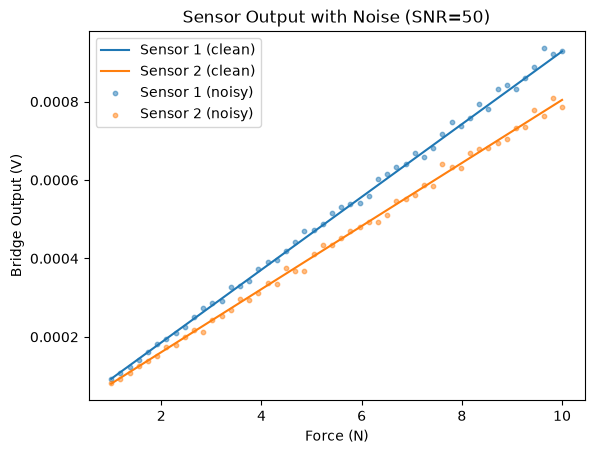

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Beam parameters
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002

I = b * t**3 / 12
c = t / 2

# ==============================
# Sensor positions
# ==============================
x1 = 0.003
x2 = 0.005

# ==============================
# Gauge parameters
# ==============================
GF = 2.0
Vex = 3.3

def full_bridge_output(strain):
    return Vex * GF * strain

# ==============================
# Force + contact location
# ==============================
forces = np.linspace(0.01, 10, 100)  # avoid 0 (for noise scaling)
x_force = 0.018  # where force is applied (near tip)

# ==============================
# Noise settings
# ==============================
SNR = 50  # signal-to-noise ratio

V1s = []
V2s = []
V1s_noisy = []
V2s_noisy = []

for F in forces:

    # strain based on arbitrary force location
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1)
    V2 = full_bridge_output(strain2)

    # Add noise
    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1s.append(V1)
    V2s.append(V2)

    V1s_noisy.append(V1 + noise1)
    V2s_noisy.append(V2 + noise2)

# ==============================
# Plot
# ==============================
plt.plot(forces, V1s, label="Sensor 1 (clean)")
plt.plot(forces, V2s, label="Sensor 2 (clean)")

plt.scatter(forces, V1s_noisy, s=10, alpha=0.5, label="Sensor 1 (noisy)")
plt.scatter(forces, V2s_noisy, s=10, alpha=0.5, label="Sensor 2 (noisy)")

plt.xlabel("Force (N)")
plt.ylabel("Bridge Output (V)")
plt.title("Sensor Output with Noise (SNR=50)")
plt.legend()
plt.show()

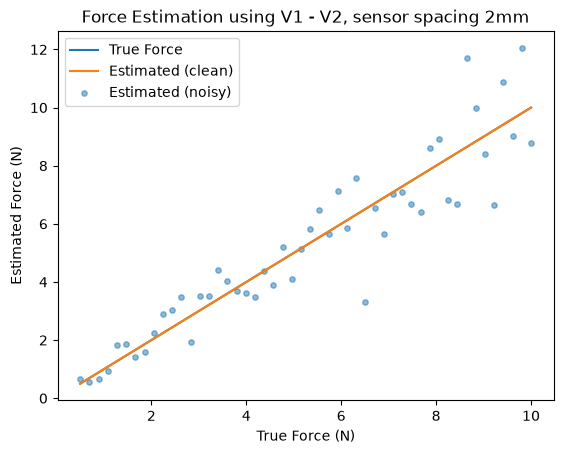

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Beam parameters
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002

I = b * t**3 / 12
c = t / 2

# ==============================
# Sensor positions
# ==============================
x1 = 0.003
x2 = 0.005

# ==============================
# Gauge parameters
# ==============================
GF = 2.0
Vex = 3.3

def full_bridge_output(strain):
    return Vex * GF * strain

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.01, 10, 50)
x_force = 0.018

# ==============================
# Noise settings
# ==============================
SNR = 50

V1_clean = []
V2_clean = []
V1_noisy = []
V2_noisy = []

for F in forces:
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1)
    V2 = full_bridge_output(strain2)

    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1_clean.append(V1)
    V2_clean.append(V2)

    V1_noisy.append(V1 + noise1)
    V2_noisy.append(V2 + noise2)

# ==============================
# Force reconstruction: V1 - V2
# ==============================

# calibration factor (derived from model)
K = (Vex * GF * c / (E * I)) * (x2 - x1)

F_est_clean = []
F_est_noisy = []

for i in range(len(forces)):
    dV_clean = V1_clean[i] - V2_clean[i]
    dV_noisy = V1_noisy[i] - V2_noisy[i]

    F_est_clean.append(dV_clean / K)
    F_est_noisy.append(dV_noisy / K)

# ==============================
# Plot
# ==============================

plt.plot(forces, forces, label="True Force")
plt.plot(forces, F_est_clean, label="Estimated (clean)")
plt.scatter(forces, F_est_noisy, s=15, alpha=0.5, label="Estimated (noisy)")

plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Force Estimation using V1 - V2, sensor spacing 2mm")
plt.legend()
plt.show()

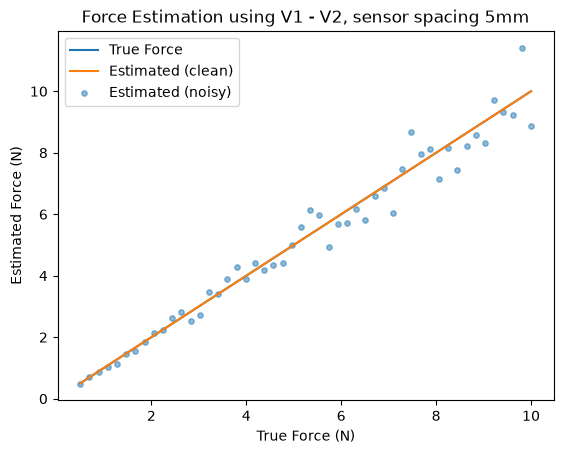

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Beam parameters
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002

I = b * t**3 / 12
c = t / 2

# ==============================
# Sensor positions
# ==============================
x1 = 0.003
x2 = 0.008

# ==============================
# Gauge parameters
# ==============================
GF = 2.0
Vex = 3.3

def full_bridge_output(strain):
    return Vex * GF * strain

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.5, 10, 50)
x_force = 0.018

# ==============================
# Noise settings
# ==============================
SNR = 50

V1_clean = []
V2_clean = []
V1_noisy = []
V2_noisy = []

for F in forces:
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1)
    V2 = full_bridge_output(strain2)

    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1_clean.append(V1)
    V2_clean.append(V2)

    V1_noisy.append(V1 + noise1)
    V2_noisy.append(V2 + noise2)

# ==============================
# Force reconstruction: V1 - V2
# ==============================

# calibration factor (derived from model)
K = (Vex * GF * c / (E * I)) * (x2 - x1)

F_est_clean = []
F_est_noisy = []

for i in range(len(forces)):
    dV_clean = V1_clean[i] - V2_clean[i]
    dV_noisy = V1_noisy[i] - V2_noisy[i]

    F_est_clean.append(dV_clean / K)
    F_est_noisy.append(dV_noisy / K)

# ==============================
# Plot
# ==============================

plt.plot(forces, forces, label="True Force")
plt.plot(forces, F_est_clean, label="Estimated (clean)")
plt.scatter(forces, F_est_noisy, s=15, alpha=0.5, label="Estimated (noisy)")

plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Force Estimation using V1 - V2, sensor spacing 5mm")
plt.legend()
plt.show()

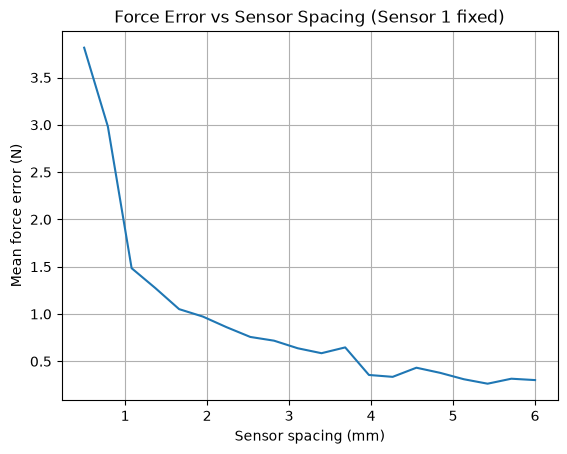

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Beam parameters
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002

I = b * t**3 / 12
c = t / 2

# ==============================
# Fixed sensor
# ==============================
x1 = 0.003   # FIXED sensor

# ==============================
# Gauge parameters
# ==============================
GF = 2.0
Vex = 3.3

def full_bridge_output(strain):
    return Vex * GF * strain

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.5, 10, 40)
x_force = 0.018

# ==============================
# Noise model
# ==============================
noise_floor = 5e-6
noise_prop = 1/50

# ==============================
# Sweep spacing
# ==============================
spacings = np.linspace(0.0005, 0.006, 20)

mean_errors = []

for d in spacings:

    x2 = x1 + d   # moving sensor

    F_errors = []

    # calibration (VERY important)
    K = (Vex * GF * c / (E * I)) * (x2 - x1)

    for F in forces:

        strain1 = (F * (x_force - x1)) * c / (E * I)
        strain2 = (F * (x_force - x2)) * c / (E * I)

        V1 = full_bridge_output(strain1)
        V2 = full_bridge_output(strain2)

        # noise (realistic)
        noise1 = noise_floor*np.random.randn() + V1*noise_prop*np.random.randn()
        noise2 = noise_floor*np.random.randn() + V2*noise_prop*np.random.randn()

        V1n = V1 + noise1
        V2n = V2 + noise2

        # force estimation
        F_est = (V1n - V2n) / K

        F_errors.append(abs(F_est - F))

    mean_errors.append(np.mean(F_errors))

# ==============================
# Plot
# ==============================
plt.plot(spacings*1000, mean_errors)
plt.xlabel("Sensor spacing (mm)")
plt.ylabel("Mean force error (N)")
plt.title("Force Error vs Sensor Spacing (Sensor 1 fixed)")
plt.grid()
plt.show()